# PAScdb example
Example on how to create CDB class

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from pyspectrum import Spectrum
from pyspectrum.calibration import AxisCalibration, ResolutionCalibration
from pyspectrum.io import TimeChannelParser
from pyspectrum.domain_analysis.single_peak import fwhm_estimator, center_estimator

from pyPAS.core import PASdb, PAScdb
from pyPAS.filter import PasCoincidenceFilter

first we load the data with the right parameters

In [2]:
# the data files from the detector (time stamps and channel)
file_1 = '../libs/cu_sample_500/detector_0/5000eV_ch000.txt'
file_2 = '../libs/cu_sample_500/detector_1/5000eV_ch001.txt'
# defnitions from the calibration

energy_calib_poly_det_1 = np.poly1d([0.0408976444, 0.0822321508])
energy_calib_poly_det_2 = np.poly1d([0.0418921521, 0.0653720462])

axis_calibration_det_1 = AxisCalibration(energy_calib_poly_det_1, name='energy')
axis_calibration_det_2 = AxisCalibration(energy_calib_poly_det_2, name='energy')

energy_resolution_511kev_det_1 = 1.05 
energy_resolution_511kev_det_2 = 1.08 

resolution_calibration_det_1 = ResolutionCalibration(lambda energy: energy_resolution_511kev_det_1 * (energy/511)**0.5)
resolution_calibration_det_2 = ResolutionCalibration(lambda energy: energy_resolution_511kev_det_2 * (energy/511)**0.5)

We want to recalibratethe energy because the center should be at 511 keV

In [3]:
data_detector_1 = pd.read_csv(file_1, skiprows=5, sep=' ', names=['time', 'channel', 'flag'], usecols=range(3))
spectrum_detector_1 = TimeChannelParser.from_dataframe(data_detector_1, axis_calibration_det_1, resolution_calibration_det_1)
db_detector_1 = PASdb.from_spectrum(spectrum_detector_1, centralize_peak=True)

data_detector_2 = pd.read_csv(file_2, skiprows=5, sep=' ', names=['time', 'channel', 'flag'], usecols=range(3))
spectrum_detector_2 = TimeChannelParser.from_dataframe(data_detector_2, axis_calibration_det_2, resolution_calibration_det_2)
db_detector_2 = PASdb.from_spectrum(spectrum_detector_2, centralize_peak=True)

with the new calibration,  filter the cdb

In [4]:
time_cdb_pairs = PasCoincidenceFilter.time_coincidence_filter(data_detector_1, data_detector_2,max_time_interval=10)

In [5]:
cdb_pairs = PasCoincidenceFilter.energy_coincidence_filter(time_cdb_pairs,
                                                           axis_calibration_1=db_detector_1.spectrum.axis_calib, 
                                                           axis_calibration_2=db_detector_2.spectrum.axis_calib, 
                                                           local_fwhm_1=db_detector_1.local_resolution,
                                                           local_fwhm_2=db_detector_2.local_resolution,
                                                           number_of_cdb_sigma=3)

In [6]:
cdb = PAScdb(cdb_pairs, energy_min=-6, energy_max=6, mesh_interval=0.1)

Text(0.5, 1.0, 'cdb of Cu (annealed to 500 degrees) measurement')

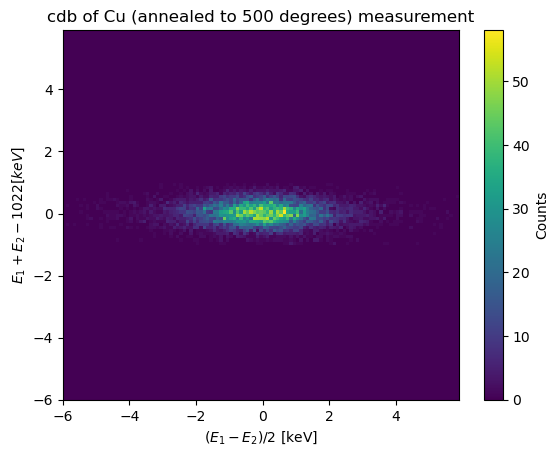

In [7]:
cdb.coincidence_map.plot(cbar_kwargs={'label': 'Counts'})
plt.xlabel('$(E_1 - E_2)/2$ [keV]')
plt.ylabel('$E_1 + E_2 - 1022 [keV]$')
plt.title('cdb of Cu (annealed to 500 degrees) measurement')


The db and resolution.
Notice the momentum distribution and how it opens in the high momenta, also note the resolution background (in some cases it's stronger)

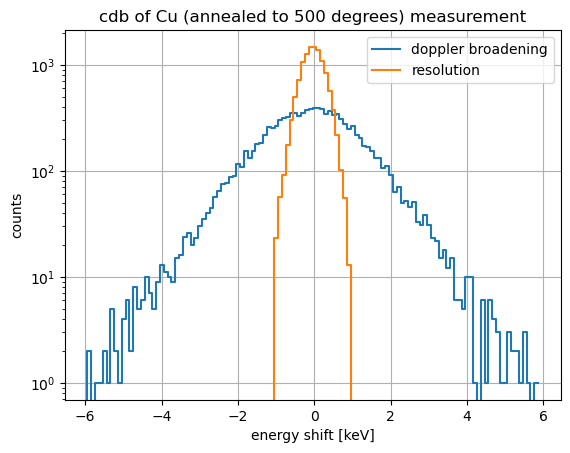

In [8]:
db_cdb = cdb.doppler_broadening(center_value=0)
res_cdb = cdb.resolution()

db_cdb.plot.step(yscale='log', label='doppler broadening')
res_cdb.plot.step(yscale='log', label='resolution')
plt.ylabel('counts')
plt.xlabel('energy shift [keV]')
plt.title('cdb of Cu (annealed to 500 degrees) measurement')
plt.legend()
plt.grid(True)

db_cdb is PASdb and can be used to calculate lineshape parameters

In [9]:
# calculate lineshpe parameters
energy_domain_s = np.array([510.2, 511.8])   - 511      # Region B (S parameter)
energy_domain_w_l = np.array([507.8, 509.3]) - 511     # Region A or C (left)
energy_domain_w_r = np.array([512.7, 514.8]) - 511        # Region A or C (right)
total_energy_domain = np.array([507.7, 514.9]) - 511
db_cdb.s_parameter_calculation(total_energy_domain, energy_domain_s), db_cdb.w_parameter_calculation(total_energy_domain, energy_domain_w_l, energy_domain_w_r)

(0.4916741473537699+/-0.00471814865388368,
 0.1700097425618648+/-0.0034623829977516885)

resolution is a domain and can be analyzed using pyspectrum

In [11]:
fwhm_estimator(res_cdb), center_estimator(res_cdb)

(np.float64(0.721833469793311), 0.03400799071913146+/-0.0017020364575754798)